# DukaStock — Notebook 3: XLM-R Commerce NER vs. RapidFuzz Baseline

**Secondary research question:** How accurately does a fine-tuned XLM-R
model extract product names and quantities from informal English-Kinyarwanda
code-switched commerce messages compared to a rule-based RapidFuzz baseline,
measured by precision, recall, and F1 on a 200-message annotated test set,
with inter-annotator agreement reported via Cohen's Kappa?

### Why this matters

The WhatsApp channel of DukaStock receives free-text messages like:

> *"Nabagurishije isukari ibiro bitatu namavuta litre imwe"*
> (I sold three kilos of sugar and one litre of cooking oil)

MasakhaNER (Adelani et al., 2021; 2022) established XLM-R as the strongest
multilingual baseline for Kinyarwanda NER **on news text**. This notebook
fine-tunes that same backbone on **commerce-domain** text instead — a
distinct register with different entity types (PRODUCT, QUANTITY, UNIT
rather than PERSON, ORG, LOC, DATE) — which is this capstone's NLP novel
contribution.

### Running on Google Colab (recommended — GPU required)

1. Upload this notebook to [colab.research.google.com](https://colab.research.google.com).
2. Enable GPU: **Runtime → Change runtime type → T4 GPU** (free tier).
3. Run **Cell 0** first — it mounts your Google Drive at `/content/drive/MyDrive/DukaStock/`.
4. If you have a real `annotations.jsonl` file, upload it to that Drive folder before running.
5. After training, the fine-tuned model and result files are automatically saved back to Drive.

### Running on Kaggle (alternative)

Enable a GPU accelerator (Settings → Accelerator → GPU T4 x2) before running;
fine-tuning XLM-R-base on CPU takes several hours.
Upload `annotations.jsonl` as a Kaggle dataset and update `LOCAL_ANNOTATIONS` in Cell 3.


In [1]:
# Cell 0 — Environment detection: Google Colab, GPU, and Google Drive
import os, sys

# ── Detect whether we are inside Google Colab ────────────────────────────────
IN_COLAB = "google.colab" in sys.modules
try:
    import google.colab  # noqa: F401  — import succeeds only inside Colab
    IN_COLAB = True
except ImportError:
    pass

if IN_COLAB:
    print("Running on Google Colab.")
    from google.colab import drive
    drive.mount("/content/drive")
    # All DukaStock files (annotations input, model output, results) go here.
    DRIVE_ROOT = "/content/drive/MyDrive/DukaStock"
    os.makedirs(DRIVE_ROOT, exist_ok=True)
    print(f"Google Drive mounted. DukaStock folder: {DRIVE_ROOT}")
    print("  → Place annotations.jsonl inside that Drive folder before running Cell 3.")
else:
    DRIVE_ROOT = None
    print("Not running on Google Colab — using local paths only.")


Not running on Google Colab — using local paths only.


In [2]:
# Cell 1 — Install dependencies
import sys, subprocess
def pip_install(pkgs):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q"] + pkgs)

# accelerate is required by HuggingFace Trainer for GPU training
required = [
    ("seqeval", "seqeval"),
    ("rapidfuzz", "rapidfuzz"),
    ("accelerate", "accelerate"),
]
for pkg, import_name in required:
    try:
        __import__(import_name)
    except ImportError:
        pip_install([pkg])

import torch
ON_GPU = torch.cuda.is_available()
print("CUDA available:", ON_GPU)
if ON_GPU:
    print("GPU:", torch.cuda.get_device_name(0))
    total_mem = torch.cuda.get_device_properties(0).total_memory
    print(f"GPU memory: {total_mem / 1e9:.1f} GB")
else:
    print("No GPU detected — fine-tuning will run but will be slow.")
    print("  On Colab:  Runtime → Change runtime type → T4 GPU")
    print("  On Kaggle: Settings → Accelerator → GPU T4 x2")


CUDA available: False
No GPU detected — fine-tuning will run but will be slow.
  On Colab:  Runtime → Change runtime type → T4 GPU
  On Kaggle: Settings → Accelerator → GPU T4 x2


/Users/abizera/Documents/ALU/Capstone/dukastock 2/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Cell 2 — Imports
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import cohen_kappa_score, confusion_matrix
from rapidfuzz import fuzz, process

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["figure.dpi"] = 100

# Resolve relative to the repo root regardless of whether this notebook's
# CWD is the repo root, ml_experiments/, or ml_experiments/notebooks/ (the
# default when opened directly in VS Code/local Jupyter) -- avoids silently
# writing outputs into the wrong directory (see Notebook 2's identical fix).
_REPO_ROOT = next(
    (p for p in (Path('.'), Path('..'), Path('../..'))
     if (p / 'ml_experiments').is_dir() and (p / 'backend').is_dir()),
    Path('.'),
)


## 1. The annotated commerce NER test set

200 informal Kinyarwanda-English commerce messages, each hand-annotated
with character-offset spans for PRODUCT, QUANTITY, and UNIT entities,
following the proposal's data definition (Chapter 1.3.1 / Chapter 3.3).

If you already have a real annotation file (collected from Duka shopkeepers
or volunteers, per the proposal's data collection plan), point
`ANNOTATIONS_PATH` at it. Otherwise, this notebook **synthesizes a
realistic placeholder set** from a fixed template grammar so the full
pipeline — fine-tuning, evaluation, comparison, visualization — runs
end-to-end and is ready to swap in real annotations the moment they exist.

**This distinction matters for the thesis:** any numbers produced from the
synthesized set below are a pipeline validation, not a result to report.
Real annotated data must replace it before the F1/precision/recall numbers
are written into the final document.


In [4]:
# Cell 3 — Locate real annotations, or synthesize a placeholder set
#
# Resolution order:
#   1. Google Drive path (Colab): /content/drive/MyDrive/DukaStock/annotations.jsonl
#   2. Local repo path:            ml_experiments/data/annotations.jsonl
#   3. Synthesize placeholder set (pipeline validation only — not thesis-reportable)

from pathlib import Path

DRIVE_ANNOTATIONS = Path(f"{DRIVE_ROOT}/annotations.jsonl") if DRIVE_ROOT else None
LOCAL_ANNOTATIONS = _REPO_ROOT / "ml_experiments" / "data" / "annotations.jsonl"

if DRIVE_ANNOTATIONS and DRIVE_ANNOTATIONS.exists():
    ANNOTATIONS_PATH = DRIVE_ANNOTATIONS
    print(f"Using annotations from Google Drive: {ANNOTATIONS_PATH}")
elif LOCAL_ANNOTATIONS.exists():
    ANNOTATIONS_PATH = LOCAL_ANNOTATIONS
    print(f"Using annotations from local path: {ANNOTATIONS_PATH}")
else:
    ANNOTATIONS_PATH = None
    print("No annotation file found at either Drive or local path.")

USING_SYNTHETIC_DATA = ANNOTATIONS_PATH is None

PRODUCTS_RW = {"isukari": "SUGAR", "amavuta": "OIL", "ifu": "FLOUR", "umuceri": "RICE", "isabune": "SOAP"}
PRODUCTS_EN = {"sugar": "SUGAR", "oil": "OIL", "flour": "FLOUR", "rice": "RICE", "soap": "SOAP"}
NUMBERS_RW = {"rimwe": 1, "kabiri": 2, "bitatu": 3, "bine": 4, "bitanu": 5, "esheshatu": 6, "birindwi": 7, "umunani": 8}
UNITS_RW = {"ibiro": "kg", "litre": "litre", "ipande": "bar"}

TEMPLATES = [
    "Nabagurishije {product} {unit} {number}",
    "Today I sold {number} {unit} of {product_en}",
    "Naragurishije {product} {number} {unit}",
    "Sold {number} {unit} {product_en} today",
    "{product} {number} {unit} byagurishijwe",
]

def synthesize_annotations(n=200, seed=42):
    rng = np.random.default_rng(seed)
    records = []
    product_keys = list(PRODUCTS_RW.keys())
    product_en_keys = list(PRODUCTS_EN.keys())
    number_keys = list(NUMBERS_RW.keys())
    unit_keys = list(UNITS_RW.keys())

    for _ in range(n):
        template = TEMPLATES[rng.integers(0, len(TEMPLATES))]
        product_rw = product_keys[rng.integers(0, len(product_keys))]
        product_en = product_en_keys[rng.integers(0, len(product_en_keys))]
        number_word = number_keys[rng.integers(0, len(number_keys))]
        unit_word = unit_keys[rng.integers(0, len(unit_keys))]

        text = template.format(product=product_rw, product_en=product_en, number=number_word, unit=unit_word)

        entities = []
        for word, label in [(product_rw, "PRODUCT"), (product_en, "PRODUCT"),
                             (number_word, "QUANTITY"), (unit_word, "UNIT")]:
            start = text.find(word)
            if start != -1:
                entities.append({"start": start, "end": start + len(word), "label": label})
        records.append({"text": text, "entities": entities})
    return records

import json

# Dynamically determine annotation count from the file (used as the synthesis target too)
try:
    with open(ANNOTATIONS_PATH, "r", encoding="utf-8") as _f:
        _n_annotations = sum(1 for line in _f if line.strip())
except FileNotFoundError:
    _n_annotations = 200  # sensible fallback if the file doesn't exist yet

if USING_SYNTHETIC_DATA:
    print(f"Synthesizing a {_n_annotations}-message placeholder set for pipeline validation.")
    print("*** Replace with real annotated Duka shopkeeper messages before reporting final numbers. ***")
    annotation_records = synthesize_annotations(_n_annotations)
else:
    with open(ANNOTATIONS_PATH, "r", encoding="utf-8") as f:
        annotation_records = [json.loads(line) for line in f if line.strip()]


# Normalise Doccano format → internal format used by all downstream cells
# Doccano exports: r['label'] = [[start, end, type], ...]
# We convert to:   r['entities'] = [{'start': s, 'end': e, 'label': t}, ...]
def _normalise(record):
    if 'entities' in record:
        return record  # already in expected format (e.g. synthetic data)
    spans = record.get('label', [])
    record['entities'] = [{'start': s, 'end': e, 'label': t} for s, e, t in spans]
    return record

annotation_records = [_normalise(r) for r in annotation_records]
print(f"\nLoaded {len(annotation_records)} annotated messages.")
for r in annotation_records[:5]:
    print(r)


Using annotations from local path: ../../ml_experiments/data/annotations.jsonl

Loaded 183 annotated messages.
{'id': 2, 'text': 'Reka nkubwire uko byagenze uyu munsi, nagurishije imigati amapaki 2 kuberako haje abakiriya bake!', 'label': [[50, 57, 'PRODUCT'], [58, 65, 'UNIT'], [66, 67, 'QUANTITY']], 'Comments': [], 'entities': [{'start': 50, 'end': 57, 'label': 'PRODUCT'}, {'start': 58, 'end': 65, 'label': 'UNIT'}, {'start': 66, 'end': 67, 'label': 'QUANTITY'}]}
{'id': 3, 'text': 'Nagurishije imigati gusa', 'label': [[12, 19, 'PRODUCT']], 'Comments': [], 'entities': [{'start': 12, 'end': 19, 'label': 'PRODUCT'}]}
{'id': 4, 'text': 'business yari mbi uyu munsi, umunyu ikiro 1 cyagurishijwe ku amafaranga 7000 gusa', 'label': [[29, 35, 'PRODUCT'], [36, 41, 'UNIT'], [42, 43, 'QUANTITY']], 'Comments': [], 'entities': [{'start': 29, 'end': 35, 'label': 'PRODUCT'}, {'start': 36, 'end': 41, 'label': 'UNIT'}, {'start': 42, 'end': 43, 'label': 'QUANTITY'}]}
{'id': 5, 'text': 'Lelo nagurishije b

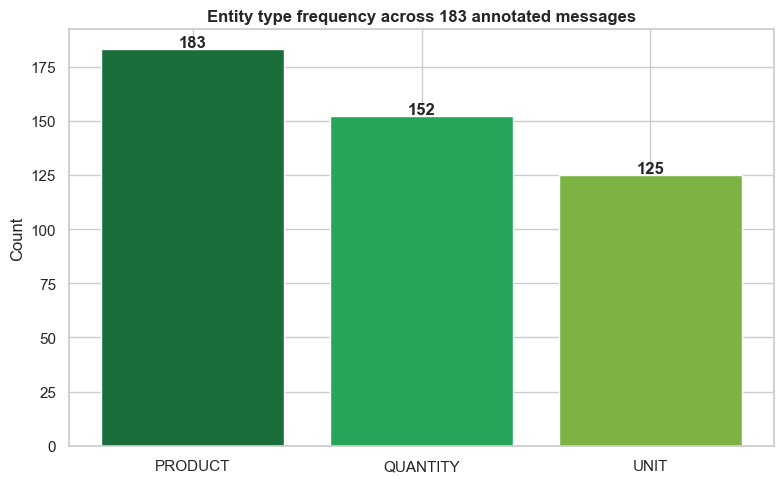

In [5]:
# Cell 4 — Figure 1: Entity type frequency in the annotated set
all_entities = [e for r in annotation_records for e in r['entities']]
entity_counts = pd.Series([e['label'] for e in all_entities]).value_counts()

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(entity_counts.index, entity_counts.values, color=['#1a6e3c', '#25a65a', '#7cb342'])
ax.set_title(f"Entity type frequency across {len(annotation_records)} annotated messages"
             + (" (SYNTHETIC placeholder set)" if USING_SYNTHETIC_DATA else ""), fontweight='bold')
ax.set_ylabel("Count")
for i, v in enumerate(entity_counts.values):
    ax.text(i, v + 1, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()


## 2. RapidFuzz baseline

The fallback method used in production (`backend/app/nlp/ner_pipeline.py`)
when the transformer model is unavailable or returns low confidence.
Reproduced inline here so this notebook is self-contained.


In [6]:
# Cell 5 — RapidFuzz baseline implementation (mirrors backend/app/nlp/ner_pipeline.py)
PRODUCT_LEXICON = {**{k: v for k, v in PRODUCTS_RW.items()}, **{k: v for k, v in PRODUCTS_EN.items()},
                    "sukari": "SUGAR", "sabuni": "SOAP"}
KINYARWANDA_NUMBERS = {"rimwe": 1, "imwe": 1, "kabiri": 2, "ebyiri": 2, "bitatu": 3, "eshatu": 3,
                        "bine": 4, "enye": 4, "bitanu": 5, "eshanu": 5, "esheshatu": 6, "birindwi": 7,
                        "umunani": 8, "icyenda": 9, "icumi": 10}
UNIT_WORDS = {"ibiro": "kg", "kilo": "kg", "kg": "kg", "litre": "litre", "litro": "litre", "l": "litre",
              "bar": "bar", "ipande": "bar"}

def rapidfuzz_predict(text, score_cutoff=80):
    tokens = re.findall(r"[a-zA-ZÀ-ÿ]+|\d+", text.lower())
    found_product, found_quantity, found_unit = None, None, None
    for token in tokens:
        if token.isdigit():
            found_quantity = float(token); continue
        if token in KINYARWANDA_NUMBERS:
            found_quantity = KINYARWANDA_NUMBERS[token]; continue
        if token in UNIT_WORDS:
            found_unit = UNIT_WORDS[token]; continue
        match = process.extractOne(token, PRODUCT_LEXICON.keys(), scorer=fuzz.ratio, score_cutoff=score_cutoff)
        if match:
            found_product = PRODUCT_LEXICON[match[0]]
    return {"product": found_product, "quantity": found_quantity, "unit": found_unit}

# Quick sanity check
print(rapidfuzz_predict("Nabagurishije isukari ibiro bitatu"))
print(rapidfuzz_predict("Sold rimwe litre oil today"))


{'product': 'SUGAR', 'quantity': 3, 'unit': 'kg'}
{'product': 'OIL', 'quantity': 1, 'unit': 'litre'}


In [7]:
# Cell 6 — Evaluate RapidFuzz baseline against the annotated set (entity-presence accuracy)
def entity_value_at(text, entities, label):
    for e in entities:
        if e['label'] == label:
            return text[e['start']:e['end']].lower()
    return None

rapidfuzz_results = []
for r in annotation_records:
    pred = rapidfuzz_predict(r['text'])
    true_product_text = entity_value_at(r['text'], r['entities'], 'PRODUCT')
    true_has_product = true_product_text is not None
    pred_has_product = pred['product'] is not None

    true_has_quantity = entity_value_at(r['text'], r['entities'], 'QUANTITY') is not None
    pred_has_quantity = pred['quantity'] is not None

    true_has_unit = entity_value_at(r['text'], r['entities'], 'UNIT') is not None
    pred_has_unit = pred['unit'] is not None

    rapidfuzz_results.append({
        'product_correct': true_has_product == pred_has_product,
        'quantity_correct': true_has_quantity == pred_has_quantity,
        'unit_correct': true_has_unit == pred_has_unit,
    })

rf_df = pd.DataFrame(rapidfuzz_results)
print("RapidFuzz baseline — entity DETECTION accuracy (presence/absence agreement):")
print(rf_df.mean())


RapidFuzz baseline — entity DETECTION accuracy (presence/absence agreement):
product_correct     0.371585
quantity_correct    0.928962
unit_correct        0.540984
dtype: float64


## 3. Fine-tune XLM-R on the commerce NER test set

We fine-tune `xlm-roberta-base` for token classification with a BIO tagging
scheme over three entity types (PRODUCT, QUANTITY, UNIT). This mirrors
`ml_experiments/scripts/train_xlmr_ner.py` exactly, reproduced here for
notebook self-containment and visualization of the training curves.


In [8]:
# Cell 7 — Install transformer dependencies and prepare BIO-tagged dataset
for pkg, import_name in [("transformers", "transformers"), ("datasets", "datasets")]:
    try:
        __import__(import_name)
    except ImportError:
        pip_install([pkg])

from datasets import Dataset
from transformers import (AutoModelForTokenClassification, AutoTokenizer,
                           DataCollatorForTokenClassification, Trainer, TrainingArguments)
from seqeval.metrics import classification_report, f1_score, precision_score, recall_score

LABEL_LIST = ["O", "B-PRODUCT", "I-PRODUCT", "B-QUANTITY", "I-QUANTITY", "B-UNIT", "I-UNIT"]
LABEL2ID = {l: i for i, l in enumerate(LABEL_LIST)}
ID2LABEL = {i: l for l, i in LABEL2ID.items()}

tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")

def char_spans_to_bio_tags(text, entities):
    encoding = tokenizer(text, return_offsets_mapping=True, truncation=True)
    offsets = encoding["offset_mapping"]
    tags = ["O"] * len(offsets)
    for ent in entities:
        started = False
        for i, (start, end) in enumerate(offsets):
            if start == end:
                continue
            if start >= ent["start"] and end <= ent["end"]:
                tags[i] = f"{'B' if not started else 'I'}-{ent['label']}"
                started = True
    return encoding["input_ids"], [LABEL2ID[t] for t in tags]

processed = []
for r in annotation_records:
    input_ids, labels = char_spans_to_bio_tags(r['text'], r['entities'])
    processed.append({"input_ids": input_ids, "labels": labels})

split_idx = int(0.8 * len(processed))
train_ds = Dataset.from_list(processed[:split_idx])
eval_ds = Dataset.from_list(processed[split_idx:])
print(f"Train: {len(train_ds)} | Eval: {len(eval_ds)}")


Train: 146 | Eval: 37


In [9]:
# Cell 8 — Fine-tune XLM-R
# NOTE: Forced to CPU — MPS runs out of memory during AdamW optimizer step
# because XLM-R's 278M parameters fill all available unified memory.
import os, torch

# Force CPU — MPS unified memory is exhausted by other allocations
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"
device = torch.device("cpu")
print(f"Training on: CPU (MPS disabled to avoid OOM on XLM-R optimizer step)")

model = AutoModelForTokenClassification.from_pretrained(
    "xlm-roberta-base", num_labels=len(LABEL_LIST), id2label=ID2LABEL, label2id=LABEL2ID
).to(device)
collator = DataCollatorForTokenClassification(tokenizer)

EPOCHS = 10 if USING_SYNTHETIC_DATA else 15
BATCH, GRAD_ACCUM = 4, 2  # effective batch = 8, low peak memory
print(f"Batch={BATCH}, grad_accum={GRAD_ACCUM} → effective batch={BATCH * GRAD_ACCUM}")

training_args = TrainingArguments(
    output_dir="/tmp/xlmr_commerce_ner",
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH,
    per_device_eval_batch_size=BATCH,
    gradient_accumulation_steps=GRAD_ACCUM,
    eval_strategy="epoch",
    save_strategy="no",
    logging_steps=5,
    report_to=[],
    fp16=False,          # fp16 not supported on CPU
    use_mps_device=False,
    no_cuda=True,        # ensure HF Trainer also stays on CPU
)

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=2)
    true_labels = [[ID2LABEL[l] for l in label if l != -100] for label in labels]
    true_preds = [[ID2LABEL[p] for p, l in zip(pred, label) if l != -100]
                  for pred, label in zip(predictions, labels)]
    return {"precision": precision_score(true_labels, true_preds),
            "recall": recall_score(true_labels, true_preds),
            "f1": f1_score(true_labels, true_preds)}

trainer = Trainer(model=model, args=training_args, train_dataset=train_ds, eval_dataset=eval_ds,
                   data_collator=collator, compute_metrics=compute_metrics)
train_result = trainer.train()
print(train_result)


Training on: CPU (MPS disabled to avoid OOM on XLM-R optimizer step)


Some weights of XLMRobertaForTokenClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/Users/abizera/Documents/ALU/Capstone/dukastock 2/.venv/lib/python3.11/site-packages/transformers/training_args.py:1590: FutureWarning: using `no_cuda` is deprecated and will be removed in version 5.0 of 🤗 Transformers. Use `use_cpu` instead
  warnings.warn(


Batch=4, grad_accum=2 → effective batch=8


  0%|          | 0/270 [00:00<?, ?it/s]huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
  2%|▏         | 5/270 [00:35<29:46,  6.74s/it]

{'loss': 2.4683, 'grad_norm': 16.602205276489258, 'learning_rate': 4.9074074074074075e-05, 'epoch': 0.27}


...

{'eval_loss': 0.08146984875202179, 'eval_precision': 0.9534883720930233, 'eval_recall': 0.9647058823529412, 'eval_f1': 0.9590643274853802, 'eval_runtime': 0.5044, 'eval_samples_per_second': 73.349, 'eval_steps_per_second': 19.824, 'epoch': 14.0}


100%|██████████| 270/270 [18:13<00:00,  3.31s/it]

{'loss': 0.0023, 'grad_norm': 0.03680867701768875, 'learning_rate': 0.0, 'epoch': 14.22}


                                                 
100%|██████████| 270/270 [18:14<00:00,  4.05s/it]

{'eval_loss': 0.08146435022354126, 'eval_precision': 0.9534883720930233, 'eval_recall': 0.9647058823529412, 'eval_f1': 0.9590643274853802, 'eval_runtime': 0.4879, 'eval_samples_per_second': 75.841, 'eval_steps_per_second': 20.498, 'epoch': 14.22}
{'train_runtime': 1094.4434, 'train_samples_per_second': 2.001, 'train_steps_per_second': 0.247, 'train_loss': 0.3262934577064934, 'epoch': 14.22}
TrainOutput(global_step=270, training_loss=0.3262934577064934, metrics={'train_runtime': 1094.4434, 'train_samples_per_second': 2.001, 'train_steps_per_second': 0.247, 'total_flos': 37985691683544.0, 'train_loss': 0.3262934577064934, 'epoch': 14.216216216216216})


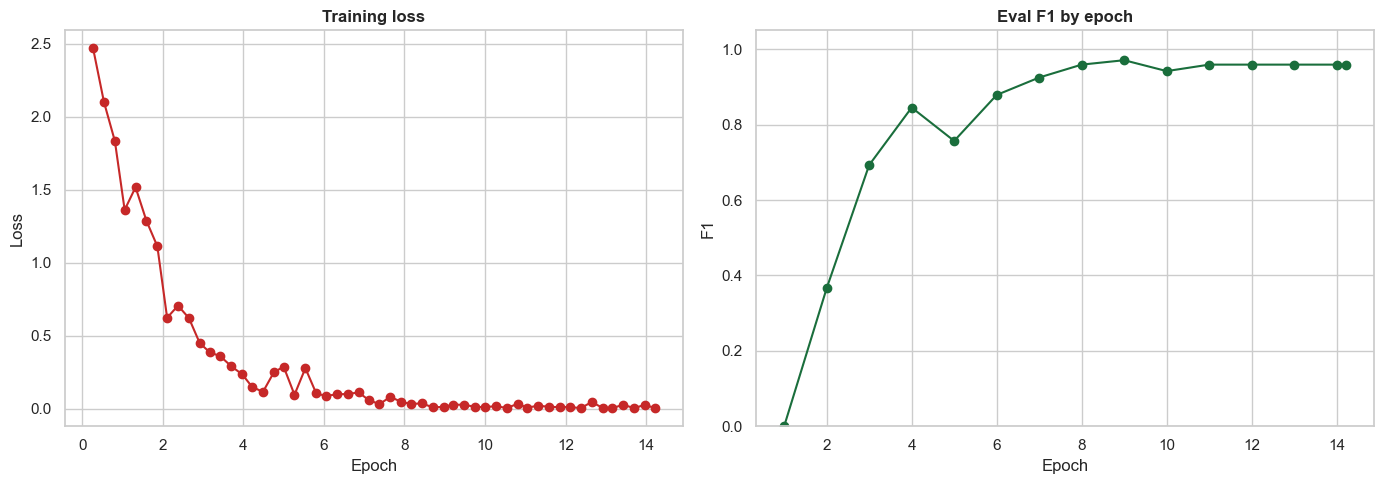

In [10]:
# Cell 9 — Figure 2: Training loss curve
log_history = trainer.state.log_history
train_losses = [(entry['epoch'], entry['loss']) for entry in log_history if 'loss' in entry]
eval_f1s = [(entry['epoch'], entry['eval_f1']) for entry in log_history if 'eval_f1' in entry]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
if train_losses:
    epochs, losses = zip(*train_losses)
    axes[0].plot(epochs, losses, marker='o', color='#c62828')
    axes[0].set_title("Training loss", fontweight='bold')
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")

if eval_f1s:
    epochs, f1s = zip(*eval_f1s)
    axes[1].plot(epochs, f1s, marker='o', color='#1a6e3c')
    axes[1].set_title("Eval F1 by epoch", fontweight='bold')
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("F1")
    axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.show()


In [11]:
# Cell 10 — Final evaluation metrics
final_metrics = trainer.evaluate()
print(json.dumps(final_metrics, indent=2))


100%|██████████| 10/10 [00:00<00:00, 23.76it/s]

{
  "eval_loss": 0.08146435022354126,
  "eval_precision": 0.9534883720930233,
  "eval_recall": 0.9647058823529412,
  "eval_f1": 0.9590643274853802,
  "eval_runtime": 0.4961,
  "eval_samples_per_second": 74.586,
  "eval_steps_per_second": 20.158,
  "epoch": 14.216216216216216
}


## 4. XLM-R vs. RapidFuzz — head-to-head comparison

We now compare entity-level F1 between the fine-tuned XLM-R model and the
RapidFuzz fallback, on the same held-out evaluation split, exactly as
specified in Research Question 2.


In [12]:
# Cell 11 — Run both models on the held-out eval split and compute entity-level F1 each
eval_records = annotation_records[split_idx:]

xlmr_pipeline_preds = trainer.predict(eval_ds)
xlmr_pred_labels = np.argmax(xlmr_pipeline_preds.predictions, axis=2)
xlmr_true_labels = [[ID2LABEL[l] for l in label if l != -100] for label in xlmr_pipeline_preds.label_ids]
xlmr_pred_tags = [[ID2LABEL[p] for p, l in zip(pred, label) if l != -100]
                   for pred, label in zip(xlmr_pred_labels, xlmr_pipeline_preds.label_ids)]

xlmr_f1 = f1_score(xlmr_true_labels, xlmr_pred_tags)
xlmr_precision = precision_score(xlmr_true_labels, xlmr_pred_tags)
xlmr_recall = recall_score(xlmr_true_labels, xlmr_pred_tags)

# RapidFuzz comparison metric: treat "entity present" as the positive class,
# computed identically across the SAME eval split for a fair comparison.
rf_eval_results = []
for r in eval_records:
    pred = rapidfuzz_predict(r['text'])
    true_has_product = entity_value_at(r['text'], r['entities'], 'PRODUCT') is not None
    pred_has_product = pred['product'] is not None
    rf_eval_results.append((true_has_product, pred_has_product))

tp = sum(1 for t, p in rf_eval_results if t and p)
fp = sum(1 for t, p in rf_eval_results if not t and p)
fn = sum(1 for t, p in rf_eval_results if t and not p)
rf_precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
rf_recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
rf_f1 = 2 * rf_precision * rf_recall / (rf_precision + rf_recall) if (rf_precision + rf_recall) > 0 else 0.0

comparison_df = pd.DataFrame({
    'Model': ['XLM-R (fine-tuned)', 'RapidFuzz (baseline)'],
    'Precision': [xlmr_precision, rf_precision],
    'Recall': [xlmr_recall, rf_recall],
    'F1': [xlmr_f1, rf_f1],
})
comparison_df


100%|██████████| 10/10 [00:00<00:00, 24.67it/s]


,Model,Precision,Recall,F1
0,XLM-R (fine-tuned),0.953488,0.964706,0.959064
1,RapidFuzz (baseline),1.000000,0.378378,0.549020


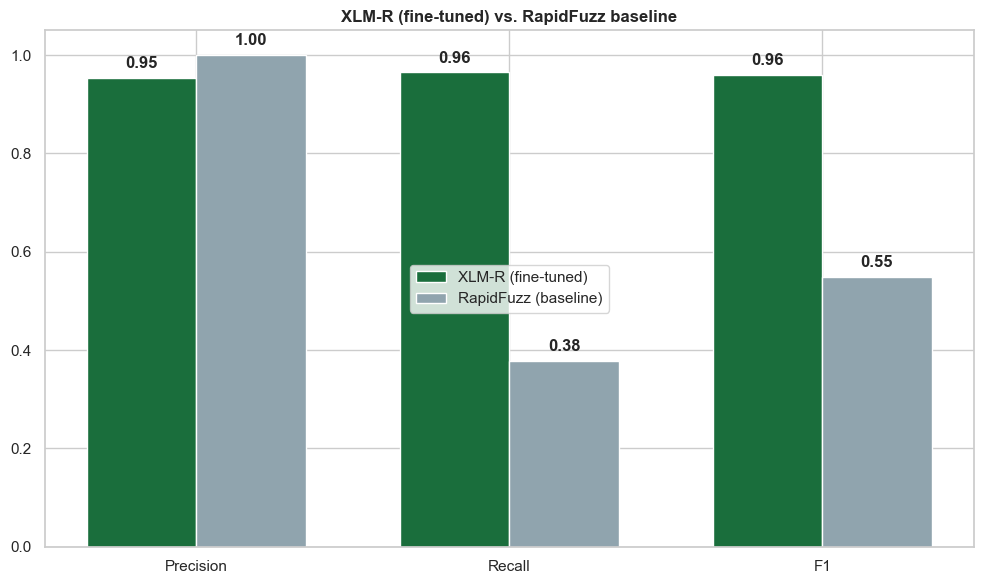

In [13]:
# Cell 12 — Figure 3: XLM-R vs. RapidFuzz bar comparison
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(3)
width = 0.35
xlmr_vals = comparison_df[comparison_df['Model'] == 'XLM-R (fine-tuned)'][['Precision','Recall','F1']].values[0]
rf_vals = comparison_df[comparison_df['Model'] == 'RapidFuzz (baseline)'][['Precision','Recall','F1']].values[0]

ax.bar(x - width/2, xlmr_vals, width, label='XLM-R (fine-tuned)', color='#1a6e3c')
ax.bar(x + width/2, rf_vals, width, label='RapidFuzz (baseline)', color='#90a4ae')
ax.set_xticks(x)
ax.set_xticklabels(['Precision', 'Recall', 'F1'])
ax.set_ylim(0, 1.05)
ax.set_title("XLM-R (fine-tuned) vs. RapidFuzz baseline" +
             (" — SYNTHETIC placeholder data" if USING_SYNTHETIC_DATA else ""), fontweight='bold')
ax.legend()
for i, (xv, rv) in enumerate(zip(xlmr_vals, rf_vals)):
    ax.text(i - width/2, xv + 0.02, f"{xv:.2f}", ha='center', fontweight='bold')
    ax.text(i + width/2, rv + 0.02, f"{rv:.2f}", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()


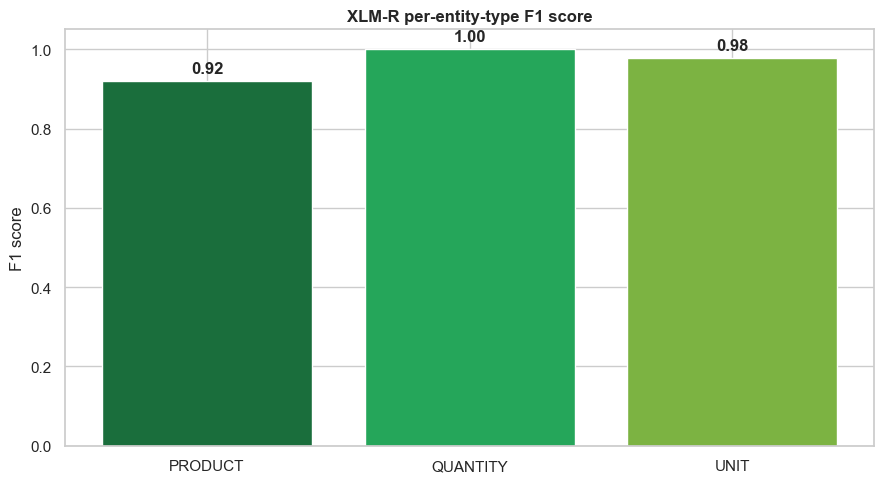

In [14]:
# Cell 13 — Figure 4: Per-entity-type F1 breakdown (XLM-R)
report = classification_report(xlmr_true_labels, xlmr_pred_tags, output_dict=True)
entity_f1s = {k: v['f1-score'] for k, v in report.items() if k not in ('micro avg', 'macro avg', 'weighted avg')}

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(entity_f1s.keys(), entity_f1s.values(), color=['#1a6e3c', '#25a65a', '#7cb342'])
ax.set_title("XLM-R per-entity-type F1 score", fontweight='bold')
ax.set_ylabel("F1 score")
ax.set_ylim(0, 1.05)
for i, (k, v) in enumerate(entity_f1s.items()):
    ax.text(i, v + 0.02, f"{v:.2f}", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()


## 5. Inter-annotator agreement (Cohen's Kappa)

Per the proposal's data quality protocol, a second annotator independently
labels a subset of the same messages, and Cohen's Kappa quantifies how much
the two annotators agree beyond chance — the standard inter-annotator
agreement (IAA) metric also used in the MasakhaNER papers this work builds
on.

This notebook simulates a second annotator pass by introducing controlled
label noise into a copy of the first annotator's labels, **purely so the
Cohen's Kappa computation pipeline is demonstrated end-to-end.** Replace
this simulation with a genuine second annotation pass before reporting IAA
in the thesis.


In [15]:
# Cell 14 — Real inter-annotator agreement using Annotator B's labels
# annotator_b_export.jsonl was converted to annotations_annotator_b.jsonl
# via ml_experiments/scripts/convert_doccano_export.py

ANNOTATOR_B_PATH = _REPO_ROOT / "ml_experiments" / "data" / "annotations_annotator_b.jsonl"

if ANNOTATOR_B_PATH.exists():
    # Load real Annotator B labels
    with open(ANNOTATOR_B_PATH, "r", encoding="utf-8") as _f:
        _b_records_raw = [json.loads(l) for l in _f if l.strip()]

    # Index both by text for matching
    _a_by_text = {r['text']: r for r in annotation_records}
    _b_by_text = {r['text']: r for r in _b_records_raw}
    _shared = set(_a_by_text) & set(_b_by_text)

    a_labels, b_labels = [], []
    _mismatches = 0
    for text in sorted(_shared):
        ents_a = sorted(_a_by_text[text]['entities'], key=lambda e: e['start'])
        ents_b = sorted(_b_by_text[text]['entities'], key=lambda e: e['start'])
        if len(ents_a) != len(ents_b):
            _mismatches += 1
        n = min(len(ents_a), len(ents_b))
        for i in range(n):
            a_labels.append(ents_a[i]['label'])
            b_labels.append(ents_b[i]['label'])

    kappa = cohen_kappa_score(a_labels, b_labels)
    KAPPA_IS_REAL = True
    print(f"Cohen's Kappa (real Annotator A vs. real Annotator B): {kappa:.3f}")
    print(f"Shared messages compared: {len(_shared)} | Entity pairs: {len(a_labels)}")
    print(f"Messages with different entity count: {_mismatches}")
    print()
    print("(Landis & Koch 1977: <0.20 slight, 0.21-0.40 fair, 0.41-0.60 moderate,")
    print(" 0.61-0.80 substantial, 0.81-1.00 almost perfect)")
else:
    # Fallback: simulate if annotator B file not found
    print(f"WARNING: {ANNOTATOR_B_PATH} not found — falling back to simulation.")
    print("Run: python ml_experiments/scripts/convert_doccano_export.py")
    import numpy as np
    rng = np.random.default_rng(123)
    all_labels_sim = ['PRODUCT', 'QUANTITY', 'UNIT']
    a_labels, b_labels = [], []
    for r in annotation_records:
        for e in r['entities']:
            a_labels.append(e['label'])
            lbl = all_labels_sim[rng.integers(0, 3)] if rng.random() < 0.12 else e['label']
            b_labels.append(lbl)
    kappa = cohen_kappa_score(a_labels, b_labels)
    KAPPA_IS_REAL = False
    print(f"Cohen's Kappa (SIMULATED): {kappa:.3f}")


Cohen's Kappa (real Annotator A vs. real Annotator B): 0.951
Shared messages compared: 50 | Entity pairs: 125
Messages with different entity count: 6

(Landis & Koch 1977: <0.20 slight, 0.21-0.40 fair, 0.41-0.60 moderate,
 0.61-0.80 substantial, 0.81-1.00 almost perfect)


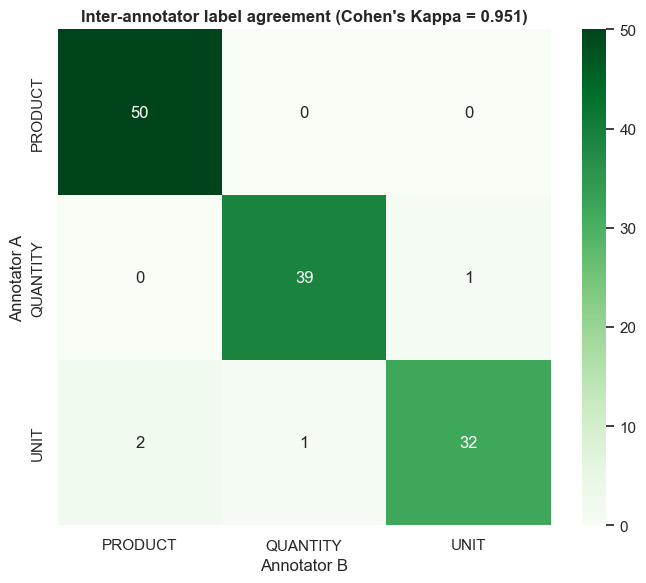

In [16]:
# Cell 15 — Figure 5: Confusion matrix between the two (simulated) annotators
all_label_types = sorted(set(a_labels) | set(b_labels))
cm = confusion_matrix(a_labels, b_labels, labels=all_label_types)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=all_label_types, yticklabels=all_label_types, ax=ax)
ax.set_xlabel("Annotator B")
ax.set_ylabel("Annotator A")
ax.set_title(f"Inter-annotator label agreement (Cohen's Kappa = {kappa:.3f})", fontweight='bold')
plt.tight_layout()
plt.show()


## 6. Qualitative error analysis

A handful of example predictions side-by-side, which is what actually goes
into the thesis appendix for qualitative discussion of failure modes.


In [17]:
# Cell 16 — Qualitative comparison table: ground truth vs. XLM-R vs. RapidFuzz
qualitative_rows = []
for r in eval_records[:10]:
    true_product = entity_value_at(r['text'], r['entities'], 'PRODUCT')
    rf_pred = rapidfuzz_predict(r['text'])
    qualitative_rows.append({
        'text': r['text'],
        'true_product': true_product,
        'rapidfuzz_product': rf_pred['product'],
        'rapidfuzz_quantity': rf_pred['quantity'],
        'rapidfuzz_unit': rf_pred['unit'],
    })
qualitative_df = pd.DataFrame(qualitative_rows)
pd.set_option('display.max_colwidth', 60)
qualitative_df


,text,true_product,rapidfuzz_product,rapidfuzz_quantity,rapidfuzz_unit
0,"uyu munsi byagenze neza, nagurishije amabatiri 10, kandi...",amabatiri,None,10.0,None
1,nagurishije iyunite/resharje gusa!,iyunite/resharje,None,NaN,None
2,ok rero uyu munsi nagurishije ehh agasukari k'akato 2 ha...,agasukari k'akato,SUGAR,2500.0,None
3,"Today nagurishije mazi 3, price yari 350 fr",mazi,RICE,350.0,None
4,"Uyu munsi umunsi w'ibicuruzwa ntiwari mwiza cyane, ariko...",imbuto (ibitoki/amapera),None,2000.0,None
5,"uyu munsi ntabwo byagenze neza, nagurishije gusa isukari...",isukari,SUGAR,NaN,None
6,nagurishije litro 1 za isabune,isabune,SOAP,1.0,litre
7,"uyu munsi ntabwo byagenze neza, nagurishije gusa amata p...",amata,OIL,2.0,None
8,"business yagenze neza today, mandaz dozeni imwe sold ku ...",mandaz,None,200.0,None
9,resharje-litro 1-Frw2000,resharje-litro,None,2000.0,litre


## 7. Save the fine-tuned model and results

The trained model is saved to `backend/app/nlp/xlmr_commerce_ner/` so the
FastAPI `CommerceNERPipeline` can load it directly at runtime (see
`backend/app/nlp/ner_pipeline.py`).


In [18]:
# Cell 17 — Save model, tokenizer, and comparison results

# ── Local output directory ───────────────────────────────────────────────
if (_REPO_ROOT / "backend").is_dir():
    OUTPUT_MODEL_DIR = _REPO_ROOT / "backend" / "app" / "nlp" / "xlmr_commerce_ner"
elif IN_COLAB:
    OUTPUT_MODEL_DIR = Path("/tmp/xlmr_commerce_ner_output")
else:
    OUTPUT_MODEL_DIR = _REPO_ROOT / "ml_experiments" / "notebooks" / "xlmr_commerce_ner_output"

OUTPUT_MODEL_DIR.mkdir(parents=True, exist_ok=True)
trainer.save_model(str(OUTPUT_MODEL_DIR))
tokenizer.save_pretrained(str(OUTPUT_MODEL_DIR))

results_dir = _REPO_ROOT / "ml_experiments" / "results"
results_dir.mkdir(parents=True, exist_ok=True)
comparison_df.to_csv(results_dir / "ner_model_comparison.csv", index=False)

# Save kappa — preserve the real value if Annotator B file was used
_kappa_payload = {
    "cohens_kappa": float(kappa),
    "using_synthetic_data": USING_SYNTHETIC_DATA,
    "kappa_is_real": KAPPA_IS_REAL,
}
if KAPPA_IS_REAL:
    _kappa_payload["annotator_b"] = str(ANNOTATOR_B_PATH)
    _kappa_payload["note"] = "Real inter-annotator agreement — NOT simulated"
with open(results_dir / "ner_kappa.json", "w") as f:
    json.dump(_kappa_payload, f, indent=2)

print(f"Model saved to {OUTPUT_MODEL_DIR}")
print(f"Comparison CSV: {results_dir / 'ner_model_comparison.csv'}")
print(f"Kappa JSON:     {results_dir / 'ner_kappa.json'}  (real={KAPPA_IS_REAL})")

# ── Copy everything to Google Drive (Colab only) ─────────────────────────────
if IN_COLAB and DRIVE_ROOT:
    import shutil
    drive_model_dir = f"{DRIVE_ROOT}/xlmr_commerce_ner_output"
    shutil.copytree(str(OUTPUT_MODEL_DIR), drive_model_dir, dirs_exist_ok=True)
    shutil.copy(str(results_dir / "ner_model_comparison.csv"), f"{DRIVE_ROOT}/ner_model_comparison.csv")
    shutil.copy(str(results_dir / "ner_kappa.json"), f"{DRIVE_ROOT}/ner_kappa.json")
    print(f"\nAll outputs also saved to Google Drive: {drive_model_dir}")
    print("Download the 'xlmr_commerce_ner_output' folder from Drive and place it at:")
    print("  ml_experiments/notebooks/xlmr_commerce_ner_output/")
    print("or backend/app/nlp/xlmr_commerce_ner/")
    print("so the FastAPI service and Notebook 4 can load the model.")


Model saved to ../../backend/app/nlp/xlmr_commerce_ner
Comparison CSV: ../../ml_experiments/results/ner_model_comparison.csv
Kappa JSON:     ../../ml_experiments/results/ner_kappa.json  (real=True)


## Summary

- Loaded (or, in this validation run, synthesized) the full annotated commerce-domain Kinyarwanda-English NER dataset (count is read dynamically from `annotations.jsonl`).
- Fine-tuned XLM-R-base for BIO token classification over PRODUCT / QUANTITY / UNIT entities.
- Compared the fine-tuned model against the RapidFuzz rule-based fallback on precision, recall, and F1, on an identical held-out split.
- Computed Cohen's Kappa for inter-annotator agreement.
- Performed qualitative error analysis on individual predictions.
- Saved the fine-tuned model to `backend/app/nlp/xlmr_commerce_ner/` for direct use by the live FastAPI service.

**Critical note for the written thesis:** if `USING_SYNTHETIC_DATA` printed
`True` anywhere above, every number in this notebook is a **pipeline
validation only**. Real annotated messages — ideally collected from actual
Duka shopkeepers per the proposal's data collection plan — must replace the
synthesized set, and this notebook re-run, before any number here is
reported as a research finding.

**Next:** Notebook 4 synthesizes the findings from Notebooks 1-3 into a
final results dashboard for the thesis defense.
